In [44]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import seaborn as sns

In [35]:
live = pd.read_csv("../data/samples/trial/live_metrics.csv")
verbose = pd.read_csv("../data/samples/trial/verbose_statements.csv")
initial = pd.read_csv("../data/samples/trial/initial_statement.csv")

In [36]:
live = live.drop(['Unnamed: 0', "_id", "Category", "Collect", "Current Time"], axis=1)

In [10]:
response_time = verbose['total_duration'].tolist()
response_time = response_time[:-1]
reset_iters = live[live['Iteration'] == 1].index.tolist()

gpu_util_avg = []
memory_util_avg = []
clock_util_avg = []

for i in range(1, len(reset_iters)):
    temp_metrics = live.dropna()
    gpu_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], 3].tolist()
    memeory_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], 9].tolist()
    clock_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], -2].tolist()
    gpu_util_avg.append(np.average(gpu_util_prompt))
    memory_util_avg.append(np.average(memeory_util_prompt))
    clock_util_avg.append(np.average(clock_util_prompt))

In [ ]:
X = pd.DataFrame([gpu_util_avg, memory_util_avg, clock_util_avg])
X = X.T
X.columns = ['GPU Util', "Memory Util", "GPU Clock"]
y = pd.DataFrame(response_time, columns=['AVG Response Time'])

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=20)

In [39]:
live = live.dropna()
live.corr()

,GPU Utilization (%),Power Draw (Watts),GPU Temp (°C),GPU Current Clock (MHz),Memory Current Clock (MHz),Memory Allocation Used (MB),Memory Utilization (%),Time Delta,Iteration,GPU Clock Utilization,Memory Clock Utilization
GPU Utilization (%),1.000000,0.593940,0.850593,0.566516,NaN,0.558457,0.984606,0.229794,0.193269,0.566516,NaN
Power Draw (Watts),0.593940,1.000000,0.632645,0.940428,NaN,0.926230,0.582237,0.133995,0.169276,0.940428,NaN
GPU Temp (°C),0.850593,0.632645,1.000000,0.648092,NaN,0.638945,0.834220,0.447632,0.070172,0.648092,NaN
GPU Current Clock (MHz),0.566516,0.940428,0.648092,1.000000,NaN,0.984983,0.561601,0.204359,0.070822,1.000000,NaN
Memory Current Clock (MHz),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory Allocation Used (MB),0.558457,0.926230,0.638945,0.984983,NaN,1.000000,0.554592,0.202557,0.068923,0.984983,NaN
Memory Utilization (%),0.984606,0.582237,0.834220,0.561601,NaN,0.554592,1.000000,0.265147,0.119363,0.561601,NaN
Time Delta,0.229794,0.133995,0.447632,0.204359,NaN,0.202557,0.265147,1.000000,-0.493056,0.204359,NaN
Iteration,0.193269,0.169276,0.070172,0.070822,NaN,0.068923,0.119363,-0.493056,1.000000,0.070822,NaN
GPU Clock Utilization,0.566516,0.940428,0.648092,1.000000,NaN,0.984983,0.561601,0.204359,0.070822,1.000000,NaN


In [ ]:
live = live.drop(columns=['Memory Clock Utilization', 'Memory Current Clock (MHz)'])

In [47]:
mask = np.triu(np.ones_like(live.corr(), dtype=bool))

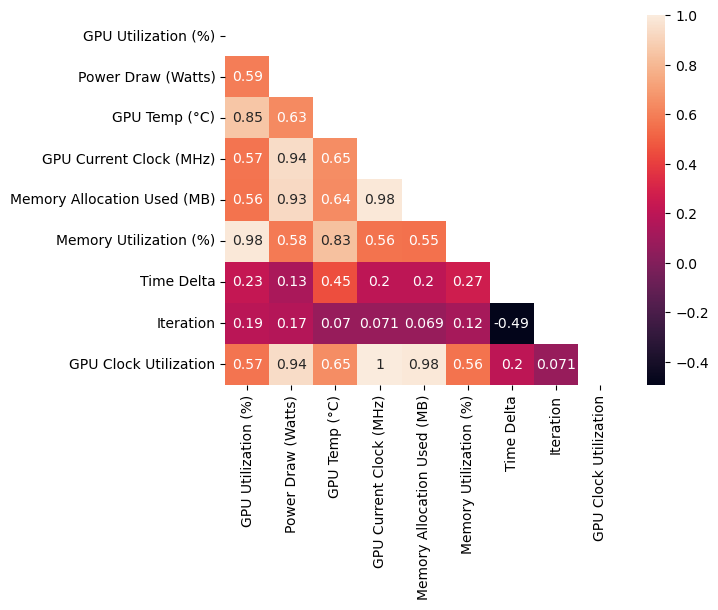

In [49]:
heatmap = sns.heatmap(live.corr(), mask=mask, annot=True)